In [3]:
# 读取高程数据，裁剪UK区域，海洋/陆地掩码，并绘制UK站点高程分布
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 1. 读取高程NetCDF数据
orog_path = '/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/Emulator_Charlie/Emulator/2015_Bristol_5D_v001/orig/Input/2018-08-01 Final report/cru-elevation.nc'  # 替换为实际的高程数据路径
ds = xr.open_dataset(orog_path)

lon=ds['lon']
lat=ds['lat']
orog=ds['elv']
# lsm=orog.where(orog>=0)


In [4]:
# crop UK region for lsm
uk_lon1, uk_lon2 = -11, 4
uk_lat1, uk_lat2 = 49, 61

# 修正经度shift逻辑，确保0-360转为-180~180
lon_shifted = xr.where(lon > 180, lon - 360, lon)
lon_shifted = lon_shifted.sortby(lon_shifted)
orog = orog.assign_coords(lon=lon_shifted)

# 检查经度范围
print('lon_shifted min:', float(lon_shifted.min()), 'max:', float(lon_shifted.max()))

# 直接用sel裁剪UK区域
orog_uk = orog.sel(lon=slice(uk_lon1, uk_lon2), lat=slice(uk_lat1, uk_lat2))
print('orog_uk shape:', orog_uk.shape)

lon_shifted min: -179.75 max: 179.75
orog_uk shape: (24, 30)


In [32]:
# 从UK_sites_index.res文件加载站点索引
import pandas as pd

# 读取CSV文件
sites_df = pd.read_csv('UK_sites_index.res')

# 转换为final_index_table格式：[(i, j, lon_val, lat_val, site_num), ...]
# 其中 i=lon_index, j=lat_index
final_index_table = []
for idx, row in sites_df.iterrows():
    lon_index = int(row['lon_index'])
    lat_index = int(row['lat_index'])
    lon_val = float(row['lon'])
    lat_val = float(row['lat'])
    site_num = int(row['site_num'])
    final_index_table.append((lon_index, lat_index, lon_val, lat_val, site_num))

print(f'已加载 {len(final_index_table)} 个站点')
print(f'第一个站点: site_num={final_index_table[0][4]}, lon={final_index_table[0][2]}, lat={final_index_table[0][3]}')

已加载 112 个站点
第一个站点: site_num=1, lon=-5.75, lat=50.25


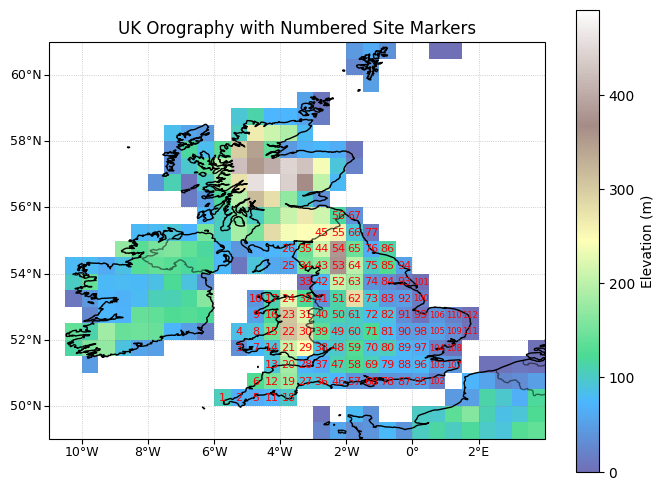

In [38]:
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import matplotlib.ticker as mticker
from shapely.ops import unary_union

plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
im = orog_uk.plot(ax=ax, cmap='terrain', add_colorbar=True,alpha=0.7)
ax.coastlines(resolution='10m')

# 添加国界线（国家边界）
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1, edgecolor='black', alpha=0.5)

# 使用 admin_1 多边形，提取 England-Scotland 与 England-Wales 的共享边界
shpfilename = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_1_states_provinces'
)
reader = shpreader.Reader(shpfilename)
uk_admin1 = [state for state in reader.records() if state.attributes.get('admin') == 'United Kingdom']

england_geoms = [state.geometry for state in uk_admin1 if state.attributes.get('geonunit') == 'England']
scotland_geoms = [state.geometry for state in uk_admin1 if state.attributes.get('geonunit') == 'Scotland']
wales_geoms = [state.geometry for state in uk_admin1 if state.attributes.get('geonunit') == 'Wales']

eng_sco_boundary = None
eng_wal_boundary = None

if england_geoms:
    england_union = unary_union(england_geoms)

    if scotland_geoms:
        scotland_union = unary_union(scotland_geoms)
        eng_sco_boundary = england_union.intersection(scotland_union)

    if wales_geoms:
        wales_union = unary_union(wales_geoms)
        eng_wal_boundary = england_union.intersection(wales_union)

# 逐段绘制线几何，确保边界线可见
def plot_boundary(geom, color, linewidth=1.0, linestyle='--'):
    if geom is None or geom.is_empty:
        return

    geom_type = geom.geom_type
    if geom_type == 'LineString':
        x, y = geom.xy
        ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle, alpha=0.7, zorder=10, transform=ccrs.PlateCarree())
    elif geom_type == 'MultiLineString':
        for line in geom.geoms:
            x, y = line.xy
            ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle, alpha=0.7, zorder=10, transform=ccrs.PlateCarree())
    elif hasattr(geom, 'geoms'):
        for subgeom in geom.geoms:
            plot_boundary(subgeom, color=color, linewidth=linewidth, linestyle=linestyle)

plot_boundary(eng_sco_boundary, color='black')
plot_boundary(eng_wal_boundary, color='black')

ax.set_title('UK Orography with Numbered Site Markers')
ax.set_xlabel(' ')
ax.set_ylabel(' ')

# 正确设置tick：用np.arange覆盖范围
lon_tick_step = 2
lat_tick_step = 2
lon_tick_start = np.ceil(orog_uk['lon'].min())
lon_tick_end = np.floor(orog_uk['lon'].max())
lat_tick_start = np.ceil(orog_uk['lat'].min())
lat_tick_end = np.floor(orog_uk['lat'].max())
lon_ticks = np.arange(lon_tick_start, lon_tick_end+1, lon_tick_step)
lat_ticks = np.arange(lat_tick_start, lat_tick_end+1, lat_tick_step)
ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())

# 添加经纬度格点线
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.6, color='gray', alpha=0.5, linestyle=':')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.FixedLocator(lon_ticks)
gl.ylocator = mticker.FixedLocator(lat_ticks)
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}



# 隐藏轴默认刻度标签，避免与gridliner标签重叠
ax.tick_params(labelbottom=False, labelleft=False)

# 用数字标记有效站点
for idx in final_index_table:
    i, j, lon_val, lat_val, site_num = idx
    if site_num > 99:
        fontsize = 6
    else:
        fontsize = 8
    ax.text(lon_val, lat_val, str(site_num), color='red', fontsize=fontsize, ha='center', va='center', transform=ccrs.PlateCarree())

# 获取colorbar对象并设置标签
cbar = im.colorbar
if cbar is not None:
    cbar.set_label('Elevation (m)')
plt.savefig('UK_site_downscaled.png', dpi=300)
plt.show()

In [29]:
import cartopy.io.shapereader as shpreader
from shapely.ops import unary_union

shpfilename = shpreader.natural_earth(
    resolution='10m',
    category='cultural',
    name='admin_1_states_provinces'
)
reader = shpreader.Reader(shpfilename)
uk_records = [r for r in reader.records() if r.attributes.get('admin') == 'United Kingdom']

england_geoms = [r.geometry for r in uk_records if r.attributes.get('geonunit') == 'England']
scotland_geoms = [r.geometry for r in uk_records if r.attributes.get('geonunit') == 'Scotland']
wales_geoms = [r.geometry for r in uk_records if r.attributes.get('geonunit') == 'Wales']

england_union = unary_union(england_geoms)
scotland_union = unary_union(scotland_geoms)
wales_union = unary_union(wales_geoms)

eng_sco_intersection = england_union.intersection(scotland_union)
eng_wal_intersection = england_union.intersection(wales_union)
eng_sco_boundary_intersection = england_union.boundary.intersection(scotland_union.boundary)
eng_wal_boundary_intersection = england_union.boundary.intersection(wales_union.boundary)

print('eng_sco_intersection type:', eng_sco_intersection.geom_type)
print('eng_wal_intersection type:', eng_wal_intersection.geom_type)
print('eng_sco_boundary_intersection type:', eng_sco_boundary_intersection.geom_type)
print('eng_wal_boundary_intersection type:', eng_wal_boundary_intersection.geom_type)

eng_sco_boundary type: MultiLineString bounds: (-3.0502913779999403, 54.981510325000045, -2.0228572259999282, 55.80548737200007)
eng_wal_boundary type: MultiLineString bounds: (-3.215122029999918, 51.617254950000074, -2.647043008999958, 53.25857168200008)


In [ ]:
# 按编号从小到大输出lat/lon的index，并保存为res文件
final_index_table_sorted = sorted(final_index_table, key=lambda x: x[4])

# 修正lon_index左偏一格（i-1），防止越界
final_index_table_sorted = [
    (max(i+1,0), j, lon_val, lat_val, site_num)
    for (i, j, lon_val, lat_val, site_num) in final_index_table_sorted
    ]

# 输出编号、lat/lon的index
for item in final_index_table_sorted:
    i, j, lon_val, lat_val, site_num = item
    print(f"site_num={site_num}, lon_index={i}, lat_index={j}, lon={lon_val}, lat={lat_val}")

# 保存为res文件
with open('UK_sites_index.res', 'w') as f:
    f.write('site_num,lon_index,lat_index,lon,lat\n')
    for item in final_index_table_sorted:
        i, j, lon_val, lat_val, site_num = item
        f.write(f"{site_num},{i},{j},{lon_val},{lat_val}\n")
print('已保存为UK_sites_index.res')

site_num=1, lon_index=11, lat_index=2, lon=-5.75, lat=50.25
site_num=2, lon_index=12, lat_index=2, lon=-5.25, lat=50.25
site_num=3, lon_index=12, lat_index=5, lon=-5.25, lat=51.75
site_num=4, lon_index=12, lat_index=6, lon=-5.25, lat=52.25
site_num=5, lon_index=13, lat_index=2, lon=-4.75, lat=50.25
site_num=6, lon_index=13, lat_index=3, lon=-4.75, lat=50.75
site_num=7, lon_index=13, lat_index=5, lon=-4.75, lat=51.75
site_num=8, lon_index=13, lat_index=6, lon=-4.75, lat=52.25
site_num=9, lon_index=13, lat_index=7, lon=-4.75, lat=52.75
site_num=10, lon_index=13, lat_index=8, lon=-4.75, lat=53.25
site_num=11, lon_index=14, lat_index=2, lon=-4.25, lat=50.25
site_num=12, lon_index=14, lat_index=3, lon=-4.25, lat=50.75
site_num=13, lon_index=14, lat_index=4, lon=-4.25, lat=51.25
site_num=14, lon_index=14, lat_index=5, lon=-4.25, lat=51.75
site_num=15, lon_index=14, lat_index=6, lon=-4.25, lat=52.25
site_num=16, lon_index=14, lat_index=7, lon=-4.25, lat=52.75
site_num=17, lon_index=14, lat_in

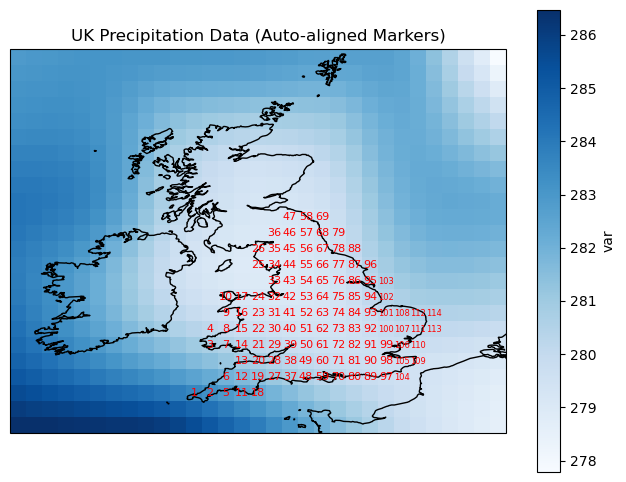

第一个站点自动对齐后编号=1, 经度=-5.5, 纬度=50.25


In [ ]:
# 读取/user/home/bo20541/downscaling_NWS/results_highres_uk/pr_modhighice_highres_natural_1_UK.nc文件
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.spatial import cKDTree
import numpy as np

# 读取nc文件
file_path = '/user/home/bo20541/downscaling_NWS/results_highres_uk/tas_modhighice_highres_SSP245_1_UK.nc'
ds = xr.open_dataset(file_path)

# 选择一个时间步（例如第一个时间步）
pr_data = ds['var'].isel(time=0)

# 获取格点中心（xarray通常是cell center）
lon_grid = pr_data['lon'].values
lat_grid = pr_data['lat'].values

# 绘图（已自动对齐）
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
im = pr_data.plot(ax=ax, cmap='Blues', add_colorbar=True)
ax.coastlines(resolution='10m')
ax.set_title('UK Precipitation Data (Auto-aligned Markers)')

# 在图上精确标记站点（自动对齐到气象数据格点）
for i_new, j_new, lon_val_old, lat_val_old, site_num in final_index_table_sorted:
    lon_val = lon_grid[i_new]
    lat_val = lat_grid[j_new]
    fontsize = 8
    if site_num > 99:  # 如果编号较大，使用更小的字体
        fontsize = 6
    ax.text(lon_val, lat_val, str(site_num), color='red', fontsize=fontsize, ha='center', va='center', transform=ccrs.PlateCarree())

plt.show()

#输出点1点经纬度（自动对齐后）
first_site = final_index_table_sorted[0]
i_new, j_new, lon_val_old, lat_val_old, site_num = first_site
lon_val = lon_grid[i_new]
lat_val = lat_grid[j_new]
print(f"第一个站点自动对齐后编号={site_num}, 经度={lon_val}, 纬度={lat_val}")

In [ ]:
print('lon_orog:', lon_vals)
print('lon_grid:', lon_grid)
print('-----')
print('lat_orog:', lat_vals)
print('lat_grid:', lat_grid)

lon_orog: [-10.75 -10.25  -9.75  -9.25  -8.75  -8.25  -7.75  -7.25  -6.75  -6.25
  -5.75  -5.25  -4.75  -4.25  -3.75  -3.25  -2.75  -2.25  -1.75  -1.25
  -0.75  -0.25   0.25   0.75   1.25   1.75   2.25   2.75   3.25   3.75]
lon_grid: [-11.  -10.5 -10.   -9.5  -9.   -8.5  -8.   -7.5  -7.   -6.5  -6.   -5.5
  -5.   -4.5  -4.   -3.5  -3.   -2.5  -2.   -1.5  -1.   -0.5   0.    0.5
   1.    1.5   2.    2.5   3.    3.5   4. ]
-----
lat_orog: [49.25 49.75 50.25 50.75 51.25 51.75 52.25 52.75 53.25 53.75 54.25 54.75
 55.25 55.75 56.25 56.75 57.25 57.75 58.25 58.75 59.25 59.75 60.25 60.75]
lat_grid: [49.25 49.75 50.25 50.75 51.25 51.75 52.25 52.75 53.25 53.75 54.25 54.75
 55.25 55.75 56.25 56.75 57.25 57.75 58.25 58.75 59.25 59.75 60.25 60.75]
